<a href="https://colab.research.google.com/github/Abdulmajeed-A/Tuwaiq-Classification-Mini-Project/blob/main/Tuwaiq_Classification_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project: Classification Algorithms Exploration
## Mobile Price Classification using K-Nearest Neighbors (KNN)

### Group Project
In this project, we apply the K-Nearest Neighbors (KNN) classification algorithm to predict the price range of mobile phones based on their technical features.

### Objective
The goal is to understand how KNN works, explore the dataset, preprocess the data, train the model, evaluate its performance, and improve the results.

## 1. Introduction

Classification is a supervised machine learning task used to predict categorical labels.  
In this project, we use the K-Nearest Neighbors (KNN) algorithm to classify mobile phones into different price ranges based on their specifications such as RAM, battery power, screen dimensions, and other features.

This project includes:
- Algorithm explanation
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Model training
- Model evaluation
- Performance improvement

## 2. Algorithm Explanation: K-Nearest Neighbors (KNN)

### What is KNN?
K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression. In classification tasks, it predicts the class of a new data point based on the majority class of its nearest neighbors.

### How does KNN work?
1. Choose a value for K (number of neighbors).
2. Calculate the distance between the new data point and all training points.
3. Select the K nearest points.
4. Assign the most common class among those neighbors.

### When should KNN be used?
KNN is useful when:
- The dataset is relatively small or medium-sized
- Similar observations are expected to belong to similar classes
- A simple and interpretable algorithm is needed

### Advantages
- Easy to understand and implement
- No complex training process
- Can perform well on well-scaled data

### Limitations
- Sensitive to feature scaling
- Slow when the dataset is large
- Can be affected by noise and irrelevant features

## 3. Dataset Overview
Before training the model, we first explore the dataset structure, feature names, missing values, and basic statistics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier

In [4]:
df = pd.read_csv("/content/train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2000, 21)

Columns:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [7]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### Dataset Overview Summary

- The dataset contains 2000 rows and 21 columns.
- All features are numerical, which makes the dataset suitable for machine learning models.
- There are no missing values in the dataset.
- There are no duplicate records.
- The target variable is `price_range`, which represents four mobile price categories.
- The statistical summary shows that feature values are on different scales, which means scaling will be important before applying KNN.

## 4. Exploratory Data Analysis (EDA)

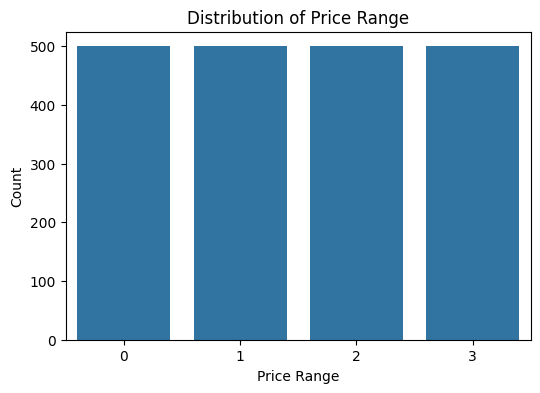

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="price_range", data=df)
plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

Insights
- The target variable is evenly distributed across all classes, indicating a balanced dataset and reducing model bias.

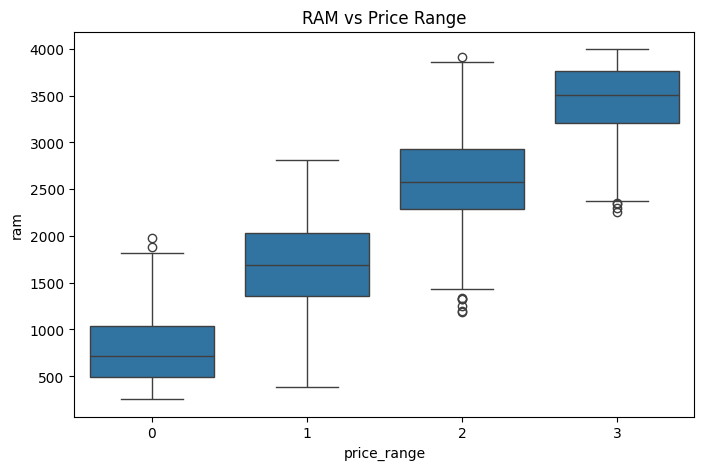

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="price_range", y="ram", data=df)
plt.title("RAM vs Price Range")
plt.show()

Insights
- RAM shows a strong positive relationship with price range.  
- Higher RAM values are associated with higher price categories, making it one of the most important features.

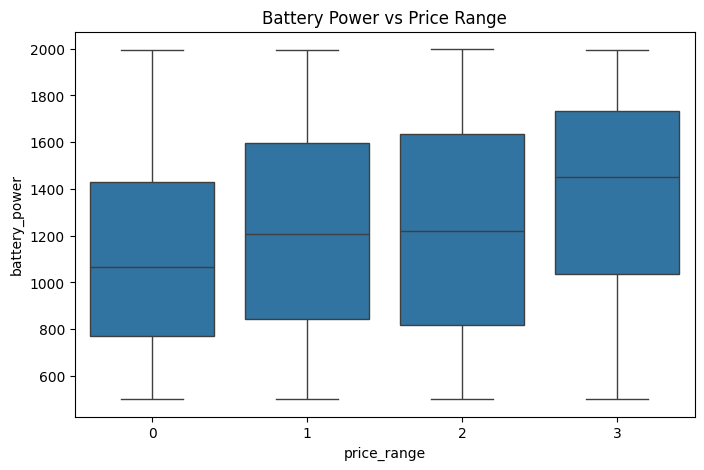

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="price_range", y="battery_power", data=df)
plt.title("Battery Power vs Price Range")
plt.show()

Insights

- Battery power shows a positive relationship with price range.  
- However, there is noticeable overlap between classes, making it less influential than RAM.

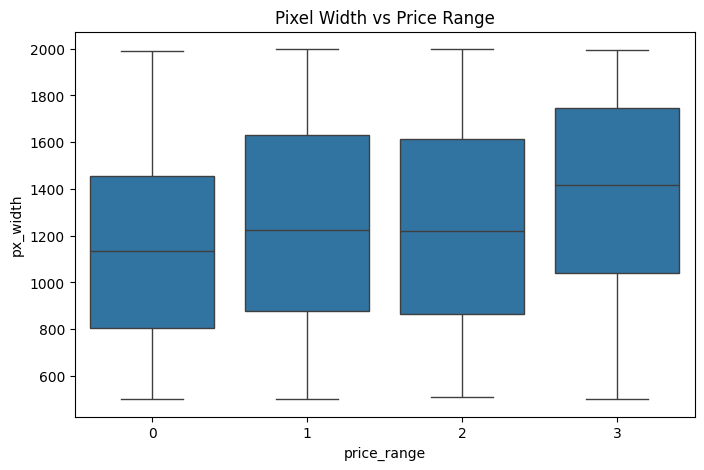

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="price_range", y="px_width", data=df)
plt.title("Pixel Width vs Price Range")
plt.show()

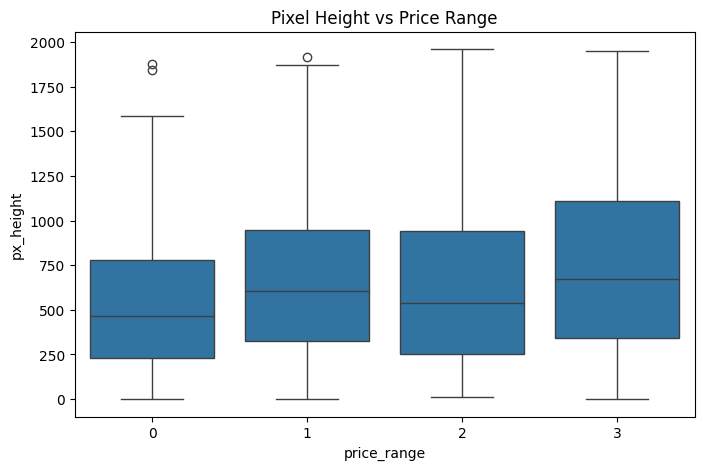

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="price_range", y="px_height", data=df)
plt.title("Pixel Height vs Price Range")
plt.show()

Insights

- Pixel width and pixel height show a positive relationship with price range.  
- Higher screen resolution is generally associated with higher price categories.  
- However, there is noticeable overlap between classes, making these features less influential than RAM.

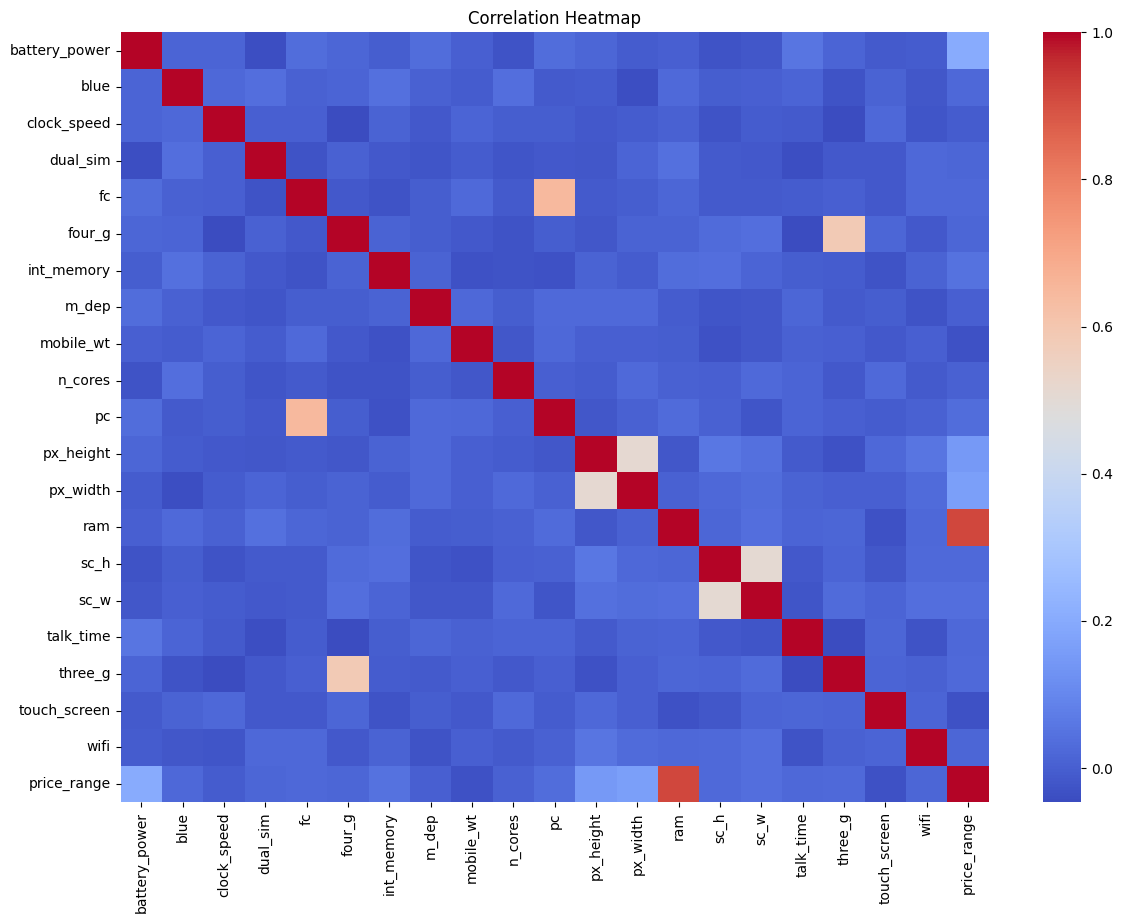

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Insights

- RAM has the strongest positive correlation with price_range, making it the most important feature.  
- Features like battery_power, px_width, and px_height show moderate correlation with the target.  
- Most features have weak correlations with each other, which is beneficial for model performance.  
- Some features such as sc_h and sc_w are highly correlated with each other, indicating similar information.

## 5. Feature Selection

Based on the exploratory data analysis and correlation results, the most relevant features were selected before training the model.

The selected features are:
- RAM
- Battery Power
- Pixel Width
- Pixel Height
- Internal Memory
- Mobile Weight
- Clock Speed
- Number of Cores

This helps reduce noise and improve the performance of the KNN classifier.

In [16]:
selected_features = [
    "ram",
    "battery_power",
    "px_width",
    "px_height",
    "int_memory",
    "mobile_wt",
    "clock_speed",
    "n_cores"
]

X = df[selected_features]
y = df["price_range"]

## 6. Data Preprocessing

Before training the model, we use the selected important features, split the data into training and testing sets, and apply feature scaling.

Feature scaling is especially important for KNN because it relies on distance calculations.

In [17]:
X = df[selected_features]
y = df["price_range"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 8)
X_test shape: (400, 8)
y_train shape: (1600,)
y_test shape: (400,)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling is essential for KNN because it relies on distance calculations.  
Without scaling, features with larger values (such as RAM) would dominate the model and lead to poor performance.